<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>



# Laboratorium nr 6: Segmentacja obrazu
Data: https://www.kaggle.com/datasets/intelecai/car-segmentation/data

Code: https://medium.com/geekculture/u-net-implementation-from-scratch-using-tensorflow-b4342266e406

In [2]:
# !pip install imageio

### Import bibliotek

In [3]:
import os

import imageio.v2 as imageio
from PIL import Image

import matplotlib.pyplot as plt

import numpy as np

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate
from tensorflow.keras.losses import binary_crossentropy
from sklearn.model_selection import train_test_split


print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)

2026-03-23 23:03:01.346592: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Numpy version: 2.4.2
Tensorflow version: 2.20.0


### Przygotowanie danych

In [4]:
def LoadData(path1, path2):
    image_dataset = os.listdir(path1)
    mask_dataset = os.listdir(path2)

    orig_img = []
    mask_img = []
    for file in image_dataset:
        orig_img.append(file)
    for file in mask_dataset:
        mask_img.append(file)
    orig_img.sort()
    mask_img.sort()
    return orig_img, mask_img

(368, 900, 3)
(368, 900)
(975, 1300, 3)
(975, 1300)


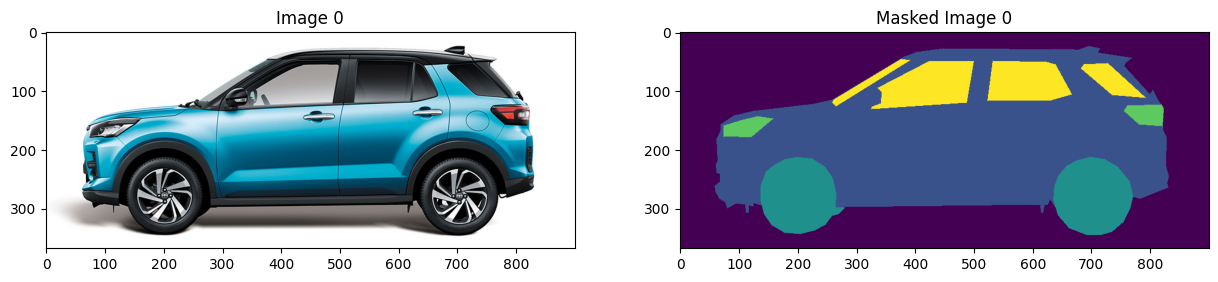

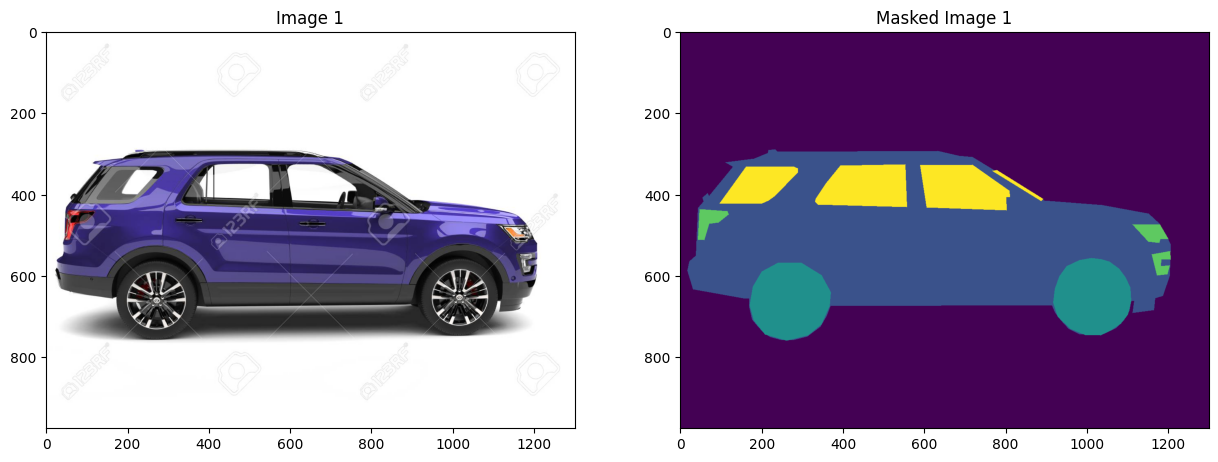

In [5]:
pathtoimg = "car-segmentation/images/"
pathtomask = "car-segmentation/masks/"
img, mask = LoadData(pathtoimg, pathtomask)

show_images = 2
for i in range(show_images):
    img_view = imageio.imread(pathtoimg + img[i])
    mask_view = imageio.imread(pathtomask + mask[i])
    print(img_view.shape)
    print(mask_view.shape)
    fig, arr = plt.subplots(1, 2, figsize=(15, 15))
    arr[0].imshow(img_view)
    arr[0].set_title("Image " + str(i))
    arr[1].imshow(mask_view)
    arr[1].set_title("Masked Image " + str(i))

In [6]:
def PreprocessData(img, mask, target_shape_img, target_shape_mask, path1, path2):
    m = len(img)
    i_h, i_w, i_c = target_shape_img
    m_h, m_w, m_c = target_shape_mask

    X = np.zeros((m, i_h, i_w, i_c), dtype=np.float32)
    y = np.zeros((m, m_h, m_w, m_c), dtype=np.int32)

    for file in img:
        index = img.index(file)
        path = os.path.join(path1, file)
        single_img = Image.open(path).convert("RGB")
        single_img = single_img.resize((i_h, i_w))
        single_img = np.reshape(single_img, (i_h, i_w, i_c))
        single_img = single_img / 256.0
        X[index] = single_img

        single_mask_ind = mask[index]
        path = os.path.join(path2, single_mask_ind)
        single_mask = Image.open(path)
        single_mask = single_mask.resize((m_h, m_w))
        single_mask = np.reshape(single_mask, (m_h, m_w, m_c))
        y[index] = single_mask
    return X, y

In [7]:
target_shape_img = [128, 128, 3]
target_shape_mask = [128, 128, 1]

X, y = PreprocessData(
    img, mask, target_shape_img, target_shape_mask, pathtoimg, pathtomask
)

print("X Shape:", X.shape)
print("Y shape:", y.shape)
print("Classes:", np.unique(y))

/home/qertal/miniconda3/envs/python312/lib/python3.12/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


X Shape: (211, 128, 128, 3)
Y shape: (211, 128, 128, 1)
Classes: [0 1 2 3 4]


Text(0.5, 1.0, 'Processed Masked Image ')

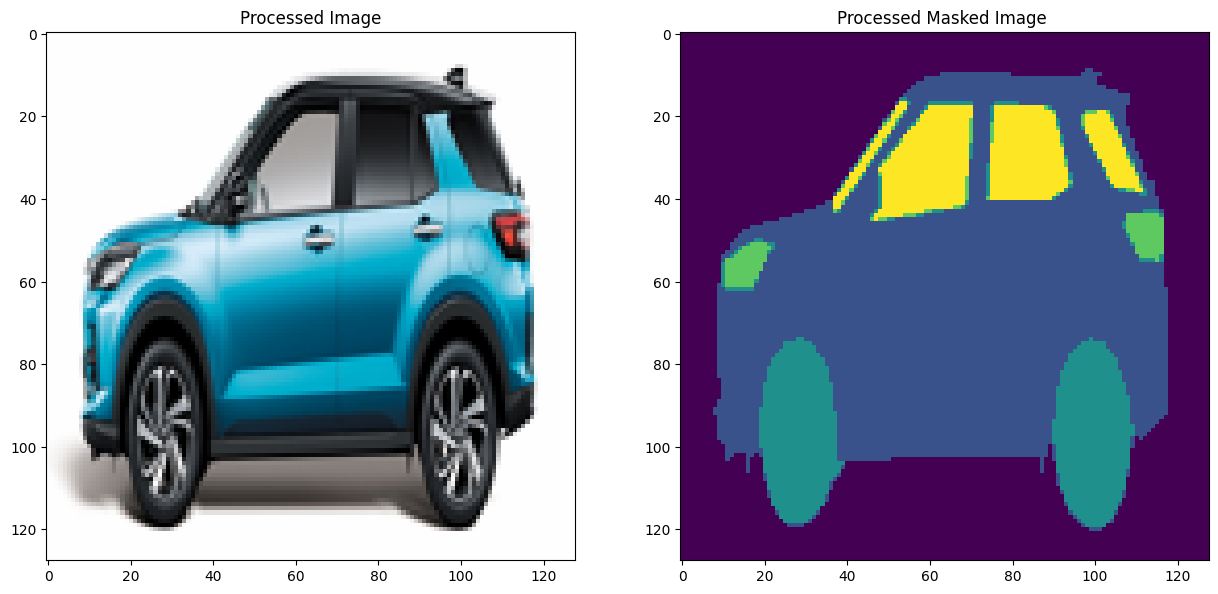

In [8]:
image_index = 0
fig, arr = plt.subplots(1, 2, figsize=(15, 15))
arr[0].imshow(X[image_index])
arr[0].set_title("Processed Image")
arr[1].imshow(y[image_index, :, :, 0])
arr[1].set_title("Processed Masked Image ")

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=123
)
print(X_train.shape, X_valid.shape)

(168, 128, 128, 3) (43, 128, 128, 3)


### Sieć U-Net
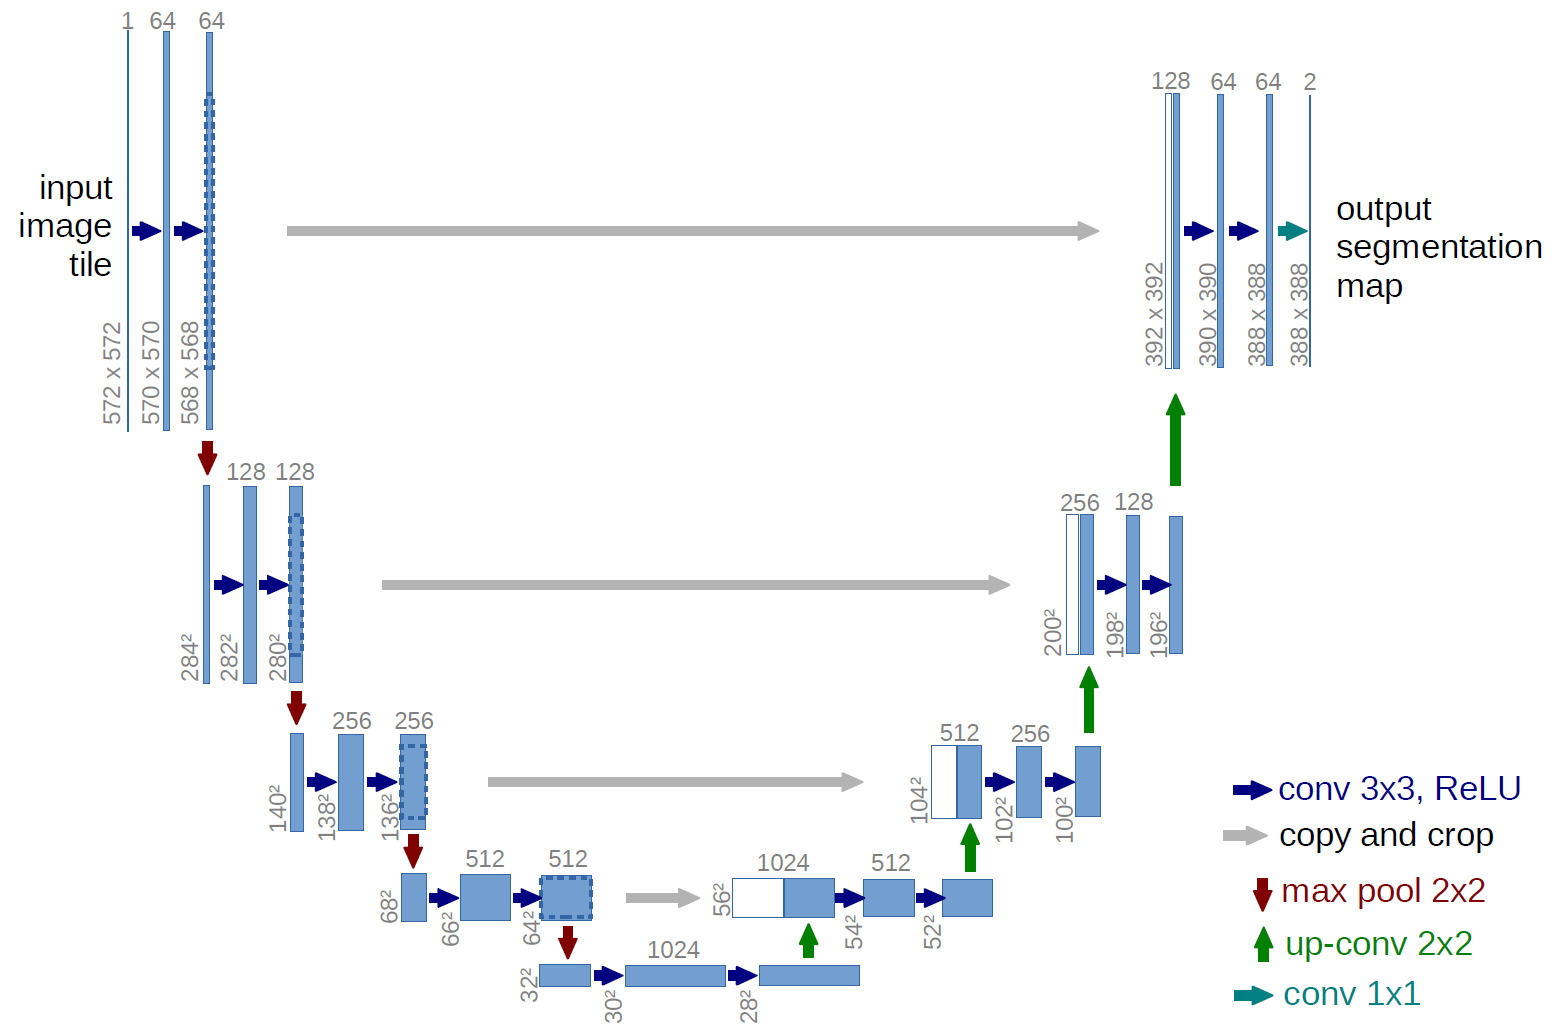

In [10]:
def EncoderMiniBlock(inputs, n_filters=32, dropout_prob=0.3, max_pooling=True):
    conv = Conv2D(
        n_filters, 3, activation="relu", padding="same", kernel_initializer="HeNormal"
    )(inputs)
    conv = Conv2D(
        n_filters, 3, activation="relu", padding="same", kernel_initializer="HeNormal"
    )(conv)

    conv = BatchNormalization()(conv, training=False)
    if dropout_prob > 0:
        conv = tf.keras.layers.Dropout(dropout_prob)(conv)

    if max_pooling:
        next_layer = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv)
    else:
        next_layer = conv

    skip_connection = conv
    return next_layer, skip_connection


def DecoderMiniBlock(prev_layer_input, skip_layer_input, n_filters=32):
    up = Conv2DTranspose(n_filters, (3, 3), strides=(2, 2), padding="same")(
        prev_layer_input
    )

    merge = concatenate([up, skip_layer_input], axis=3)

    conv = Conv2D(
        n_filters, 3, activation="relu", padding="same", kernel_initializer="HeNormal"
    )(merge)
    conv = Conv2D(
        n_filters, 3, activation="relu", padding="same", kernel_initializer="HeNormal"
    )(conv)
    return conv


def UNetCompiled(input_size=(128, 128, 3), n_filters=32, n_classes=5):
    inputs = Input(input_size)

    cblock1 = EncoderMiniBlock(inputs, n_filters, dropout_prob=0, max_pooling=True)
    cblock2 = EncoderMiniBlock(
        cblock1[0], n_filters * 2, dropout_prob=0, max_pooling=True
    )
    cblock3 = EncoderMiniBlock(
        cblock2[0], n_filters * 4, dropout_prob=0, max_pooling=True
    )
    cblock4 = EncoderMiniBlock(
        cblock3[0], n_filters * 8, dropout_prob=0.3, max_pooling=True
    )
    cblock5 = EncoderMiniBlock(
        cblock4[0], n_filters * 16, dropout_prob=0.3, max_pooling=False
    )

    ublock6 = DecoderMiniBlock(cblock5[0], cblock4[1], n_filters * 8)
    ublock7 = DecoderMiniBlock(ublock6, cblock3[1], n_filters * 4)
    ublock8 = DecoderMiniBlock(ublock7, cblock2[1], n_filters * 2)
    ublock9 = DecoderMiniBlock(ublock8, cblock1[1], n_filters)

    conv9 = Conv2D(
        n_filters, 3, activation="relu", padding="same", kernel_initializer="he_normal"
    )(ublock9)
    conv10 = Conv2D(n_classes, 1, padding="same")(conv9)

    model = tf.keras.Model(inputs=inputs, outputs=conv10)
    return model

In [11]:
unet = UNetCompiled(input_size=(128, 128, 3), n_filters=4, n_classes=5)
unet.summary()

I0000 00:00:1774303411.504464    1565 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4078 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        112 │ input_layer[0][0] │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │        148 │ conv2d[0][0]      │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         16 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64, 4) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64, 8) │        296 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64, 8) │        584 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64, 8) │         32 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32, 8) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      1,168 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      2,320 │ conv2d_4[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │      4,640 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 135,989 (531.21 KB)

 Trainable params: 135,741 (530.24 KB)

 Non-trainable params: 248 (992.00 B)

In [12]:
unet.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint

cb = [ModelCheckpoint("model_unet.keras", monitor="val_loss", save_best_only=True)]
results = unet.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=100,
    validation_data=(X_valid, y_valid),
    callbacks=cb,
)

Epoch 1/100


2026-03-23 23:03:42.993915: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f1a840039f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-23 23:03:42.993955: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2026-03-23 23:03:43.292013: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-23 23:03:44.475959: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-23 23:03:46.125745: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-23 23:03:47.555513: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy

 8/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5022 - loss: 1.5692

2026-03-23 23:04:02.268329: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-23 23:04:03.826816: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,4,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3,128,128]{3,2,1,0}, f32[4,3,3,3]{3,2,1,0}, f32[4]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-23 23:04:03.927705: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4940 - loss: 1.5545  

2026-03-23 23:04:16.409497: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-23 23:04:16.485047: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,4,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,128,128]{3,2,1,0}, f32[4,3,3,3]{3,2,1,0}, f32[4]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-23 23:04:16.596436: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng

11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.4693 - loss: 1.5067 - val_accuracy: 0.5752 - val_loss: 1.5288
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.4627 - loss: 1.2016 - val_accuracy: 0.5275 - val_loss: 1.3678
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5385 - loss: 1.0488 - val_accuracy: 0.5684 - val_loss: 1.2950
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6179 - loss: 0.9361 - val_accuracy: 0.6211 - val_loss: 2.0321
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6756 - loss: 0.8411 - val_accuracy: 0.6226 - val_loss: 2.6657
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6809 - loss: 0.7933 - val_accuracy: 0.6226 - val_loss: 3.0371
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6969 - loss: 0.7434 - val_accuracy: 0.6235 - val_loss: 2.4348
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7251 - loss: 0.7109 - val_accuracy: 0.6229 - val_lo

### Wyniki

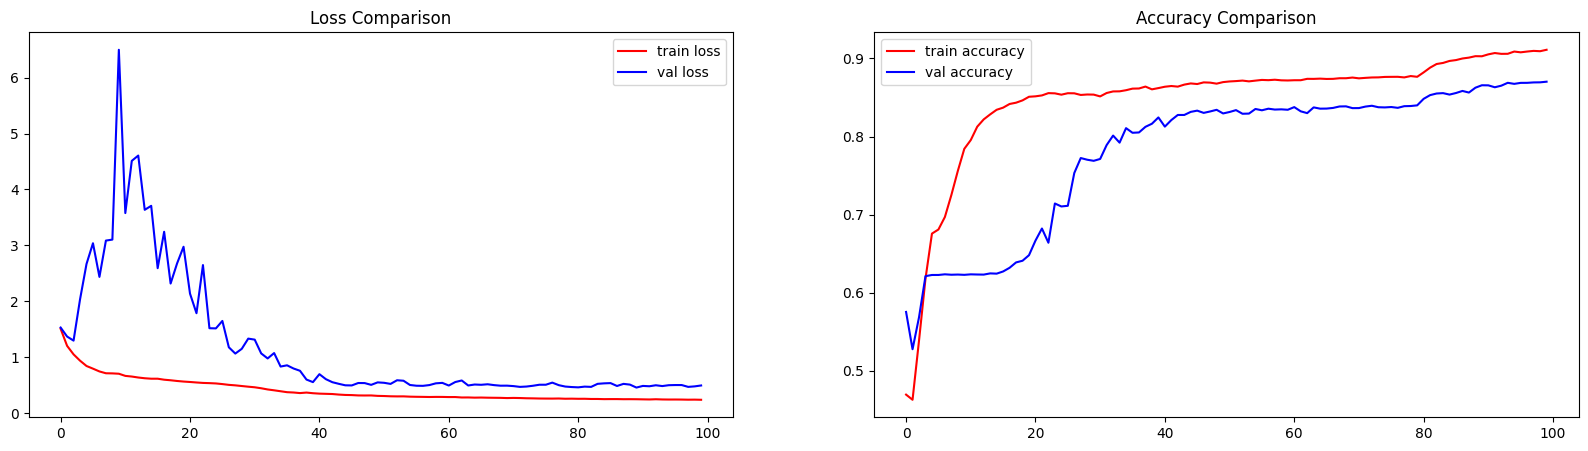

In [14]:
fig, axis = plt.subplots(1, 2, figsize=(20, 5))
axis[0].plot(results.history["loss"], color="r", label="train loss")
axis[0].plot(results.history["val_loss"], color="b", label="val loss")
axis[0].set_title("Loss Comparison")
axis[0].legend()
axis[1].plot(results.history["accuracy"], color="r", label="train accuracy")
axis[1].plot(results.history["val_accuracy"], color="b", label="val accuracy")
axis[1].set_title("Accuracy Comparison")
axis[1].legend()

In [15]:
funet = tf.keras.models.load_model("model_unet.keras")
funet.evaluate(X_valid, y_valid)

2026-03-23 23:05:07.153369: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-23 23:05:07.280012: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,4,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,128,128]{3,2,1,0}, f32[4,3,3,3]{3,2,1,0}, f32[4]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-23 23:05:07.546967: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng

1/2 ━━━━━━━━━━━━━━━━━━━━ 3s 4s/step - accuracy: 0.8669 - loss: 0.4681

2026-03-23 23:05:09.996399: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8657 - loss: 0.4549


[0.4549335241317749, 0.8657099008560181]

In [16]:
def VisualizeResults(index):
    img = X_valid[index]
    # img = X_train[index]
    img = img[np.newaxis, ...]
    pred_y = funet.predict(img)
    pred_mask = tf.argmax(pred_y[0], axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    fig, arr = plt.subplots(1, 3, figsize=(15, 15))
    arr[0].imshow(X_valid[index])
    arr[0].set_title("Processed Image")
    arr[1].imshow(y_valid[index, :, :, 0])
    arr[1].set_title("Actual Masked Image ")
    arr[2].imshow(pred_mask[:, :, 0])
    arr[2].set_title("Predicted Masked Image ")

2026-03-23 23:05:12.157265: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,16,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,8,32,32]{3,2,1,0}, f32[16,8,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-23 23:05:12.232650: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,16,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,16,32,32]{3,2,1,0}, f32[16,16,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$c

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


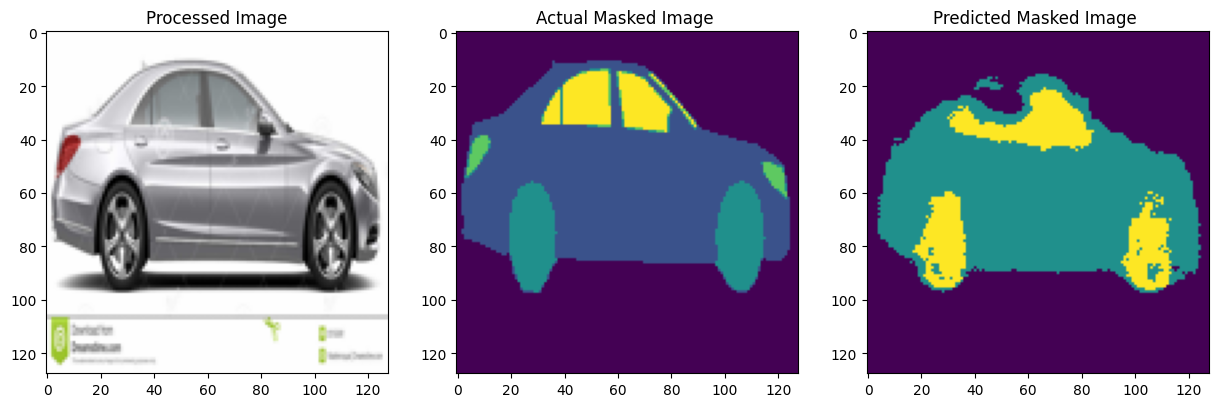

In [17]:
index = 11
VisualizeResults(index)

## Ćwiczenie 1
Zmodyfikować i dotrenować model. Spróbować poradzić sobie z problemem przeuczenia (modyfikacja architektury, augumentacja danych itp.).

In [ ]:
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Podział danych
X_train_ex1, X_temp_ex1, y_train_ex1, y_temp_ex1 = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_valid_ex1, X_test_ex1, y_valid_ex1, y_test_ex1 = train_test_split(
    X_temp_ex1, y_temp_ex1, test_size=0.50, random_state=42
)

print("Shapes:")
print("Train:", X_train_ex1.shape, y_train_ex1.shape)
print("Valid:", X_valid_ex1.shape, y_valid_ex1.shape)
print("Test :", X_test_ex1.shape, y_test_ex1.shape)

Shapes:
Train: (147, 128, 128, 3) (147, 128, 128, 1)
Valid: (32, 128, 128, 3) (32, 128, 128, 1)
Test : (32, 128, 128, 3) (32, 128, 128, 1)


In [ ]:
# Augmentacja danych
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE_EX1 = 8
EPOCHS_EX1 = 25


def augment_pair(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    image = tf.image.random_brightness(image, max_delta=0.08)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask


def make_dataset(images, masks, training=False):
    ds = tf.data.Dataset.from_tensor_slices((images, masks))
    if training:
        ds = ds.shuffle(buffer_size=len(images), reshuffle_each_iteration=True)
        ds = ds.map(augment_pair, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE_EX1).prefetch(AUTOTUNE)
    return ds


train_dataset_ex1 = make_dataset(X_train_ex1, y_train_ex1, training=True)
valid_dataset_ex1 = make_dataset(X_valid_ex1, y_valid_ex1, training=False)
test_dataset_ex1 = make_dataset(X_test_ex1, y_test_ex1, training=False)

In [ ]:
# U-Net z regularyzacją
def EncoderMiniBlockEx1(
    inputs, n_filters=32, dropout_prob=0.0, max_pooling=True, l2w=1e-4
):
    conv = Conv2D(
        n_filters,
        3,
        activation="relu",
        padding="same",
        kernel_initializer="HeNormal",
        kernel_regularizer=regularizers.l2(l2w),
    )(inputs)
    conv = BatchNormalization()(conv)

    conv = Conv2D(
        n_filters,
        3,
        activation="relu",
        padding="same",
        kernel_initializer="HeNormal",
        kernel_regularizer=regularizers.l2(l2w),
    )(conv)
    conv = BatchNormalization()(conv)

    if dropout_prob > 0:
        conv = layers.SpatialDropout2D(dropout_prob)(conv)

    if max_pooling:
        next_layer = MaxPooling2D(pool_size=(2, 2))(conv)
    else:
        next_layer = conv

    skip_connection = conv
    return next_layer, skip_connection


def DecoderMiniBlockEx1(
    prev_layer_input, skip_layer_input, n_filters=32, dropout_prob=0.0, l2w=1e-4
):
    up = Conv2DTranspose(
        n_filters,
        (3, 3),
        strides=(2, 2),
        padding="same",
        kernel_regularizer=regularizers.l2(l2w),
    )(prev_layer_input)
    merge = concatenate([up, skip_layer_input], axis=3)

    conv = Conv2D(
        n_filters,
        3,
        activation="relu",
        padding="same",
        kernel_initializer="HeNormal",
        kernel_regularizer=regularizers.l2(l2w),
    )(merge)
    conv = BatchNormalization()(conv)

    conv = Conv2D(
        n_filters,
        3,
        activation="relu",
        padding="same",
        kernel_initializer="HeNormal",
        kernel_regularizer=regularizers.l2(l2w),
    )(conv)
    conv = BatchNormalization()(conv)

    if dropout_prob > 0:
        conv = layers.SpatialDropout2D(dropout_prob)(conv)

    return conv


def UNetCompiledEx1(input_size=(128, 128, 3), n_filters=16, n_classes=5, l2w=1e-4):
    inputs = Input(input_size)

    cblock1 = EncoderMiniBlockEx1(
        inputs, n_filters, dropout_prob=0.05, max_pooling=True, l2w=l2w
    )
    cblock2 = EncoderMiniBlockEx1(
        cblock1[0], n_filters * 2, dropout_prob=0.10, max_pooling=True, l2w=l2w
    )
    cblock3 = EncoderMiniBlockEx1(
        cblock2[0], n_filters * 4, dropout_prob=0.15, max_pooling=True, l2w=l2w
    )
    cblock4 = EncoderMiniBlockEx1(
        cblock3[0], n_filters * 8, dropout_prob=0.20, max_pooling=True, l2w=l2w
    )
    cblock5 = EncoderMiniBlockEx1(
        cblock4[0], n_filters * 16, dropout_prob=0.30, max_pooling=False, l2w=l2w
    )

    ublock6 = DecoderMiniBlockEx1(
        cblock5[0], cblock4[1], n_filters * 8, dropout_prob=0.20, l2w=l2w
    )
    ublock7 = DecoderMiniBlockEx1(
        ublock6, cblock3[1], n_filters * 4, dropout_prob=0.15, l2w=l2w
    )
    ublock8 = DecoderMiniBlockEx1(
        ublock7, cblock2[1], n_filters * 2, dropout_prob=0.10, l2w=l2w
    )
    ublock9 = DecoderMiniBlockEx1(
        ublock8, cblock1[1], n_filters, dropout_prob=0.05, l2w=l2w
    )

    conv9 = Conv2D(
        n_filters,
        3,
        activation="relu",
        padding="same",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(l2w),
    )(ublock9)

    outputs = Conv2D(n_classes, 1, padding="same")(conv9)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


unet_ex1 = UNetCompiledEx1(
    input_size=(128, 128, 3), n_filters=16, n_classes=5, l2w=1e-4
)
unet_ex1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
unet_ex1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_60[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 128, 128,  │      2,320 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_61[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_9 │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 64, 64,    │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_62[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 64, 64,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_… │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 32, 32,    │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_13… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_64[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 32, 32,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_65[0][0] 

 Total params: 2,166,981 (8.27 MB)

 Trainable params: 2,164,037 (8.26 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
# Trenowanie z callbackami
callbacks_ex1 = [
    ModelCheckpoint(
        "model_unet_ex1.keras", monitor="val_loss", save_best_only=True, verbose=1
    ),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
]

results_ex1 = unet_ex1.fit(
    train_dataset_ex1,
    validation_data=valid_dataset_ex1,
    epochs=EPOCHS_EX1,
    callbacks=callbacks_ex1,
    verbose=1,
)

Epoch 1/25


2026-03-23 23:16:09.825862: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


17/19 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2412 - loss: 2.2583

2026-03-23 23:16:31.646978: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2541 - loss: 2.2262  

2026-03-23 23:16:51.277046: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert



Epoch 1: val_loss improved from None to 160.11949, saving model to model_unet_ex1.keras

Epoch 1: finished saving model to model_unet_ex1.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.3661 - loss: 1.9478 - val_accuracy: 0.3086 - val_loss: 160.1195 - learning_rate: 0.0010
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6680 - loss: 1.3951
Epoch 2: val_loss improved from 160.11949 to 82.90899, saving model to model_unet_ex1.keras

Epoch 2: finished saving model to model_unet_ex1.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6896 - loss: 1.3136 - val_accuracy: 0.3228 - val_loss: 82.9090 - learning_rate: 0.0010
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7492 - loss: 1.0939
Epoch 3: val_loss improved from 82.90899 to 32.07980, saving model to model_unet_ex1.keras

Epoch 3: finished saving model to model_unet_ex1.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.7537 - loss: 1.0659 - val_accuracy: 0.5744 - val_loss:

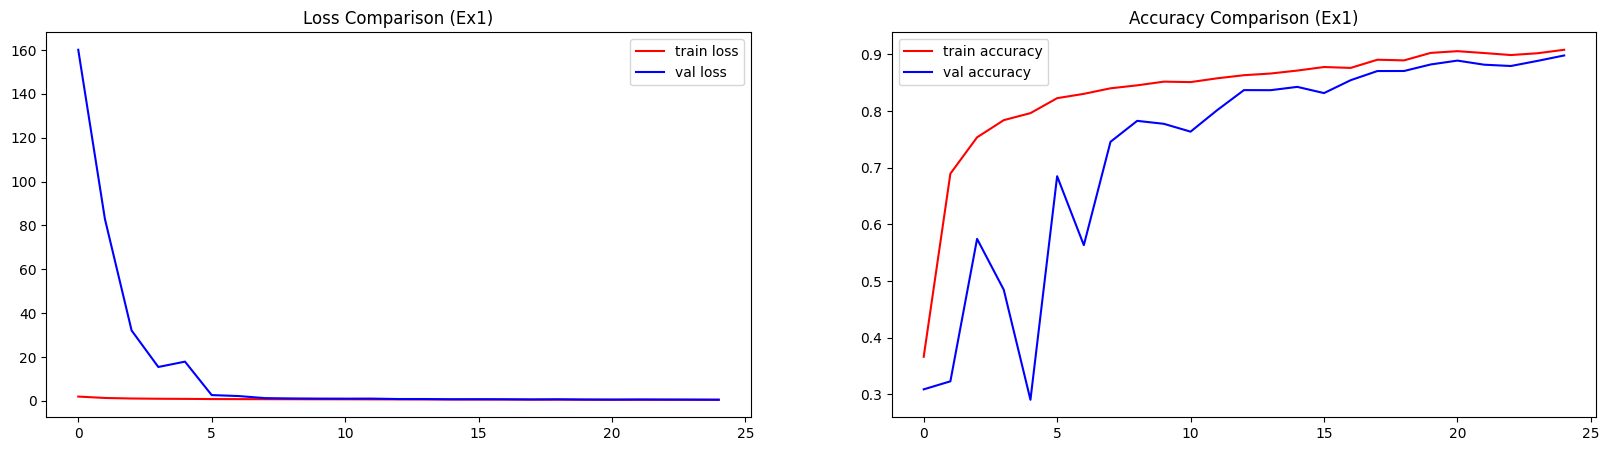

In [ ]:
# Wykresy uczenia
fig, axis = plt.subplots(1, 2, figsize=(20, 5))
axis[0].plot(results_ex1.history["loss"], color="r", label="train loss")
axis[0].plot(results_ex1.history["val_loss"], color="b", label="val loss")
axis[0].set_title("Loss Comparison (Ex1)")
axis[0].legend()
axis[1].plot(results_ex1.history["accuracy"], color="r", label="train accuracy")
axis[1].plot(results_ex1.history["val_accuracy"], color="b", label="val accuracy")
axis[1].set_title("Accuracy Comparison (Ex1)")
axis[1].legend()
plt.show()

In [ ]:
# Ewaluacja na zbiorze testowym
best_unet_ex1 = tf.keras.models.load_model("model_unet_ex1.keras")
test_metrics_ex1 = best_unet_ex1.evaluate(test_dataset_ex1, verbose=1)
print("Test loss:", test_metrics_ex1[0])
print("Test accuracy:", test_metrics_ex1[1])

2026-03-23 23:17:24.795794: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9218 - loss: 0.4439
Test loss: 0.4439081847667694
Test accuracy: 0.9217758178710938


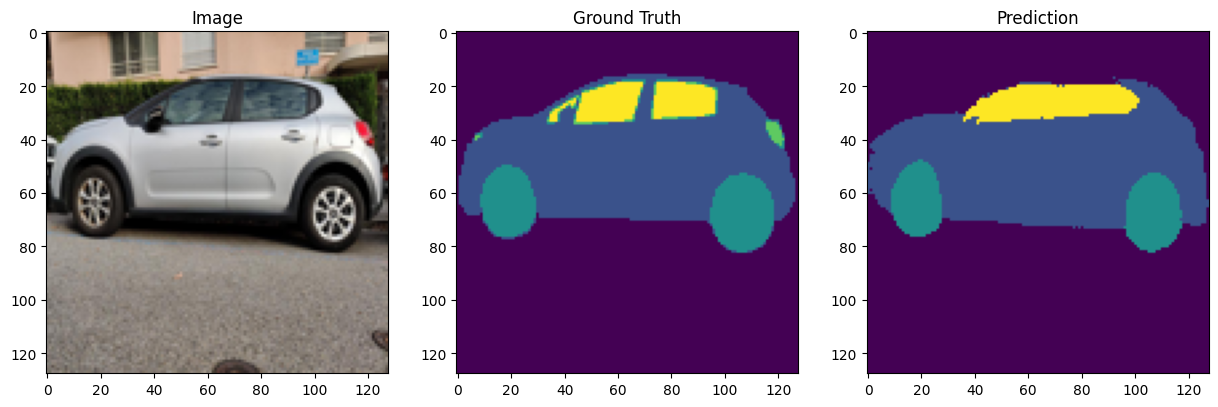

2026-03-23 23:17:30.345367: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# Wizualizacja predykcji
example_index_ex1 = 0
for images_batch, masks_batch in test_dataset_ex1.take(1):
    pred_logits = best_unet_ex1.predict(images_batch, verbose=0)
    pred_masks = tf.argmax(pred_logits, axis=-1)

    fig, arr = plt.subplots(1, 3, figsize=(15, 5))
    arr[0].imshow(images_batch[example_index_ex1])
    arr[0].set_title("Image")
    arr[1].imshow(masks_batch[example_index_ex1, :, :, 0], cmap="viridis")
    arr[1].set_title("Ground Truth")
    arr[2].imshow(pred_masks[example_index_ex1], cmap="viridis")
    arr[2].set_title("Prediction")
    plt.show()